# Solution : CNN pour la Vision par Ordinateur (CIFAR-10)

Ce notebook contient la solution complète de l'exercice 2.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import Sequential, layers, optimizers, callbacks
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


## Tâche 1 : Chargement et Exploration

In [2]:
# Charger CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Flatten y
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ['avion', 'automobile', 'oiseau', 'chat', 'cerf', 'chien', 'grenouille', 'cheval', 'bateau', 'camion']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Pixel range: [{X_train.min()}, {X_train.max()}]")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000,)
Pixel range: [0, 255]


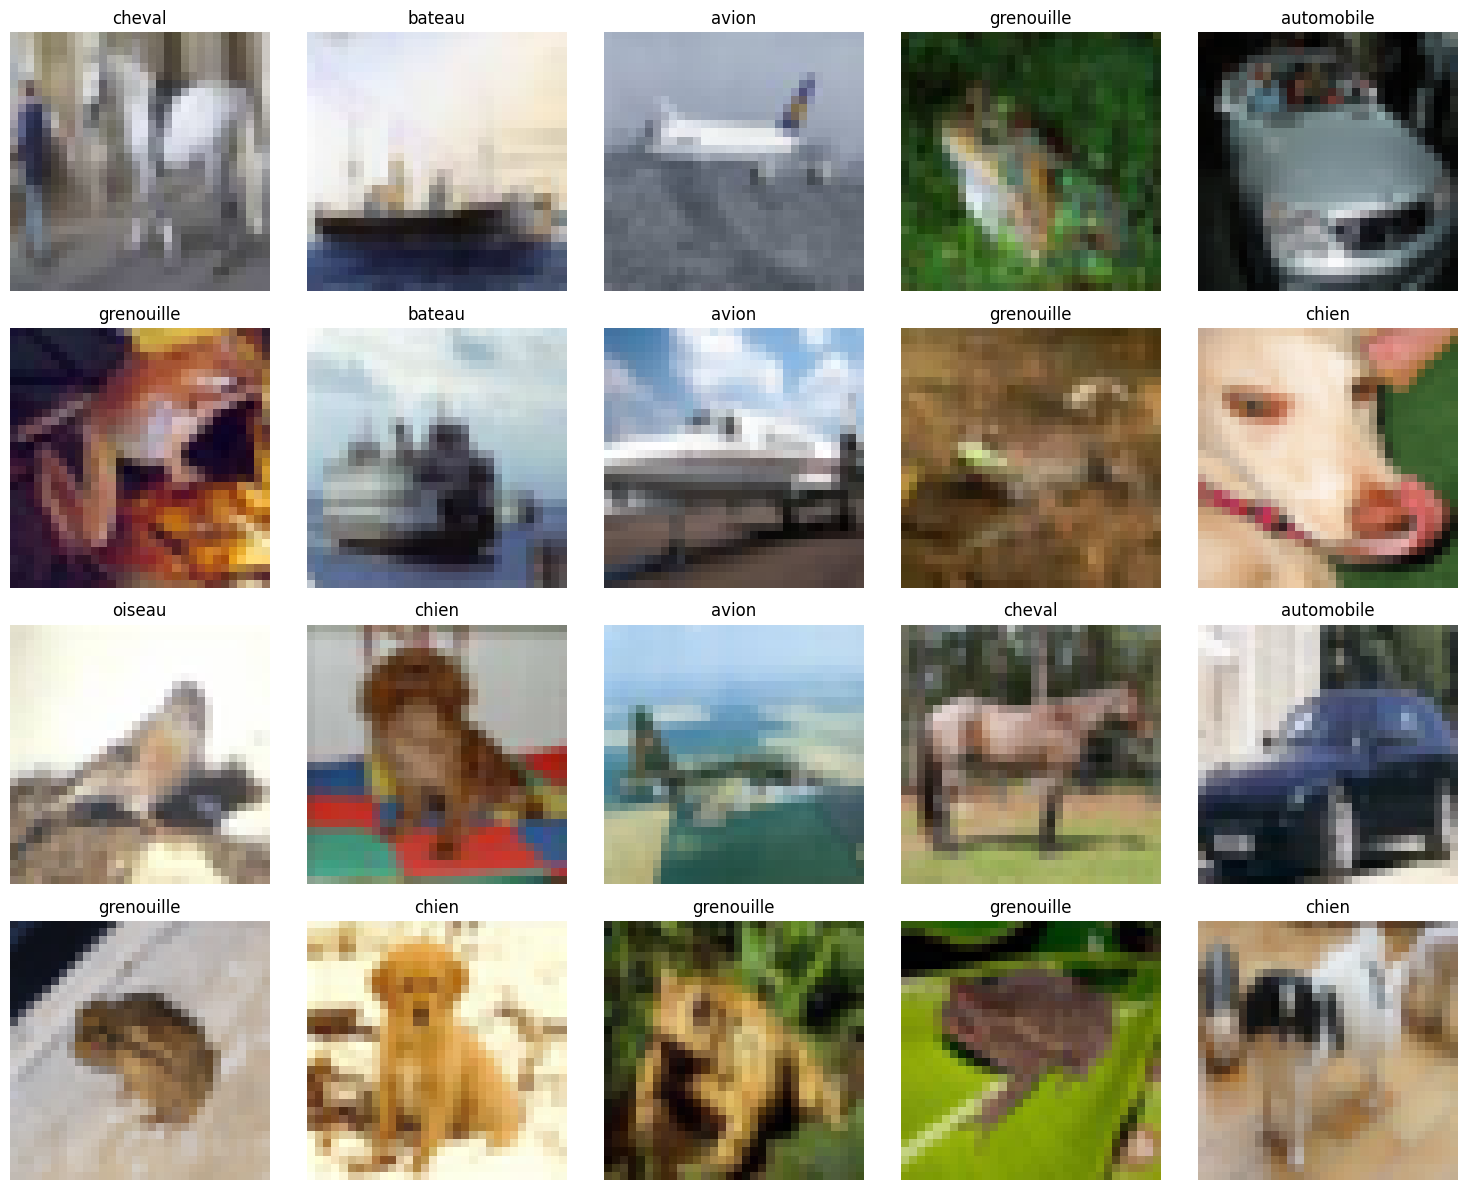

In [3]:
# Visualiser 20 images aléatoires
np.random.seed(42)
indices = np.random.choice(len(X_train), 20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
for i, (idx, ax) in enumerate(zip(indices, axes.flat)):
    ax.imshow(X_train[idx])
    ax.set_title(f'{class_names[y_train[idx]]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

Distribution des classes (train):
  avion           (0): 5000 images
  automobile      (1): 5000 images
  oiseau          (2): 5000 images
  chat            (3): 5000 images
  cerf            (4): 5000 images
  chien           (5): 5000 images
  grenouille      (6): 5000 images
  cheval          (7): 5000 images
  bateau          (8): 5000 images
  camion          (9): 5000 images


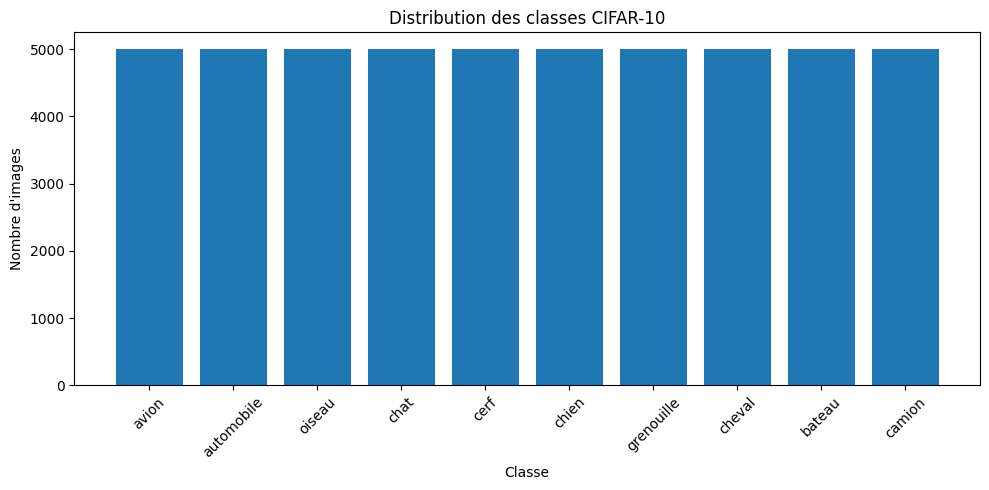

In [4]:
# Distribution des classes
unique, counts = np.unique(y_train, return_counts=True)
print("Distribution des classes (train):")
for label, count in zip(unique, counts):
    print(f"  {class_names[label]:15} ({label}): {count} images")

plt.figure(figsize=(10, 5))
plt.bar([class_names[i] for i in unique], counts)
plt.xlabel('Classe')
plt.ylabel('Nombre d\'images')
plt.title('Distribution des classes CIFAR-10')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
# Normaliser les pixels
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)

print(f"Données normalisées")
print(f"X_train_norm range: [{X_train_norm.min():.3f}, {X_train_norm.max():.3f}]")

Données normalisées
X_train_norm range: [0.000, 1.000]


## Tâche 2 : Architecture CNN Simple

In [6]:
# Modèle CNN simple
model_simple = Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_simple.compile(
    optimizer=optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_simple.summary()

c:\Users\Administrateur\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entraîner le modèle
history_simple = model_simple.fit(
    X_train_norm, y_train_onehot,
    batch_size=32,
    epochs=15,
    validation_split=0.2,
    verbose=1
)

# Évaluer
test_loss_simple, test_acc_simple = model_simple.evaluate(X_test_norm, y_test_onehot, verbose=0)
print(f"\nTest Accuracy: {test_acc_simple:.4f}")

Epoch 1/15
 466/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2624 - loss: 1.9813

## Tâche 3 : CNN Profond

In [ ]:
# CNN Profond avec Batch Normalization
model_deep = Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Dense
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_deep.compile(
    optimizer=optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_deep.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 849,066 (3.24 MB)

 Trainable params: 847,402 (3.23 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [ ]:
# Entraîner le modèle profond
history_deep = model_deep.fit(
    X_train_norm, y_train_onehot,
    batch_size=32,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

# Évaluer
test_loss_deep, test_acc_deep = model_deep.evaluate(X_test_norm, y_test_onehot, verbose=0)
print(f"\nTest Accuracy (CNN Deep): {test_acc_deep:.4f}")

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 35ms/step - accuracy: 0.4472 - loss: 1.5697 - val_accuracy: 0.5928 - val_loss: 1.1493
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.6429 - loss: 1.0221 - val_accuracy: 0.6778 - val_loss: 0.9202
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.7096 - loss: 0.8385 - val_accuracy: 0.7241 - val_loss: 0.7921
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.7573 - loss: 0.7126 - val_accuracy: 0.7523 - val_loss: 0.7088
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.7922 - loss: 0.6172 - val_accuracy: 0.7597 - val_loss: 0.6894
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.8239 - loss: 0.5204 - val_accuracy: 0.8004 - val_loss: 0.5848
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.8493 - loss: 0.4455 - val_accuracy: 0.7808 - val_loss: 0.6593
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.8719 -

## Tâche 4 : Évaluation Complète

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


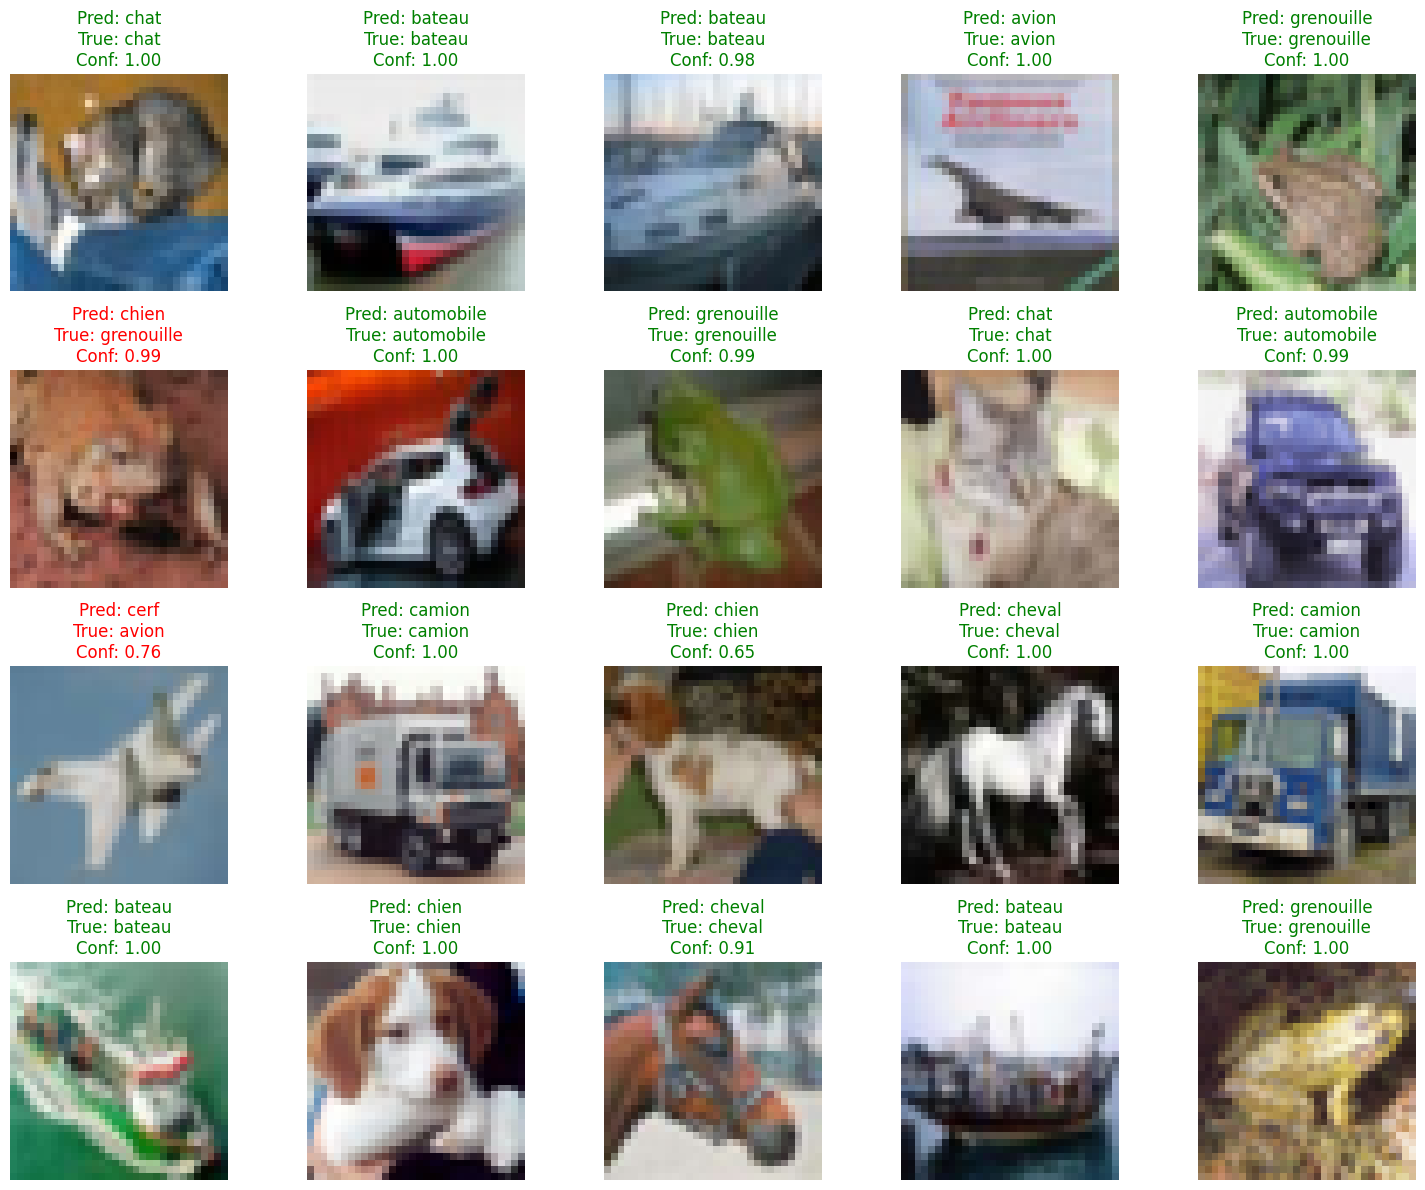

In [ ]:
# Utiliser le meilleur modèle (Deep)
best_model = model_deep

# Prédictions sur 20 images test
predictions = best_model.predict(X_test_norm[:20])
pred_classes = np.argmax(predictions, axis=1)
pred_confidence = np.max(predictions, axis=1)

# Visualiser
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
for i, ax in enumerate(axes.flat):
    pred = pred_classes[i]
    true = y_test[i]
    conf = pred_confidence[i]
    correct = pred == true
    
    ax.imshow(X_test[i])
    color = 'green' if correct else 'red'
    ax.set_title(f'Pred: {class_names[pred]}\nTrue: {class_names[true]}\nConf: {conf:.2f}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Total errors: 1896/10000 (19.0%)


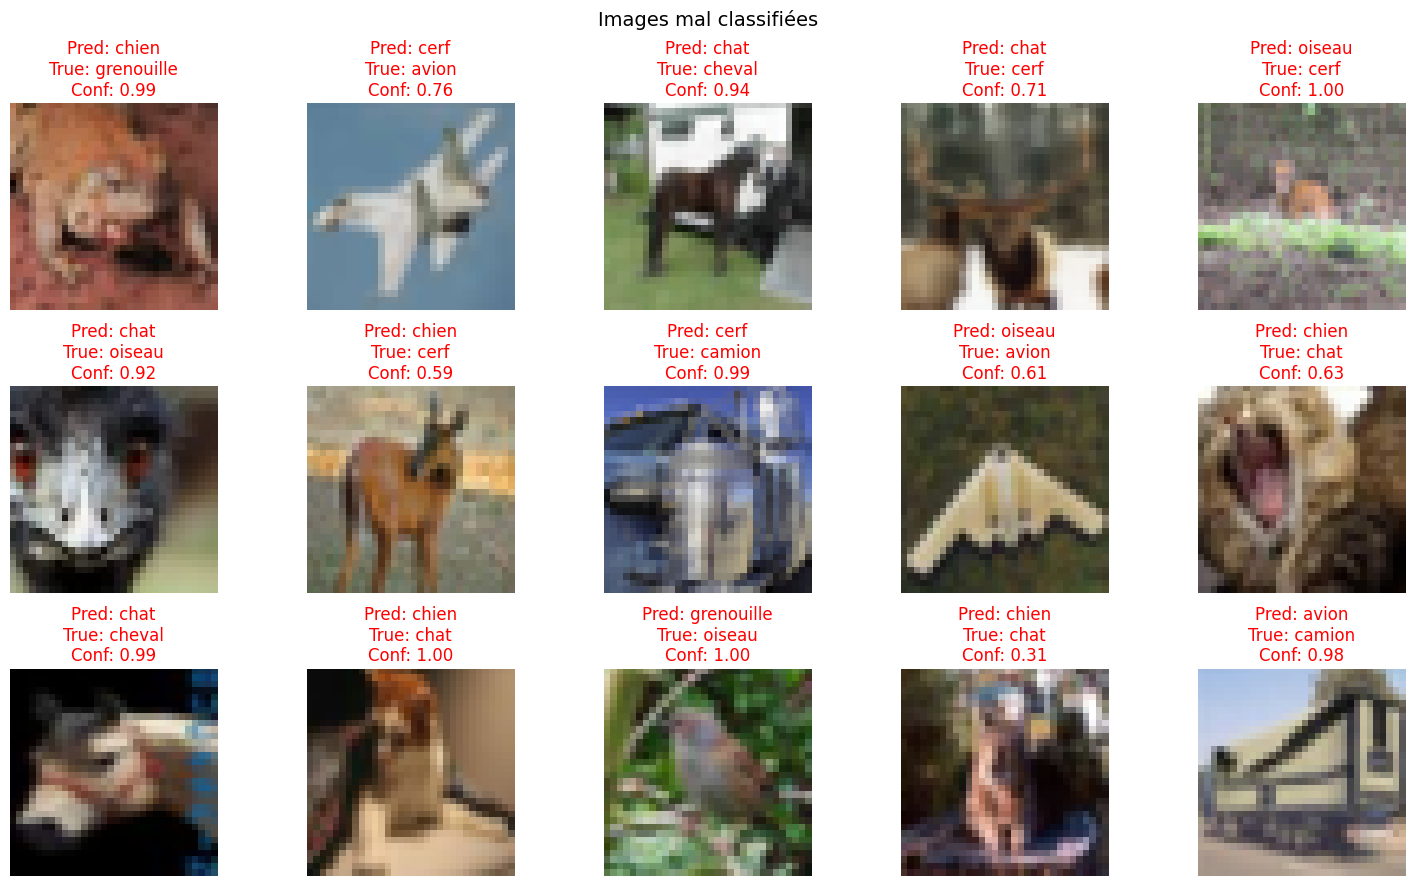

In [ ]:
# Identifier les erreurs
predictions_all = best_model.predict(X_test_norm)
pred_classes_all = np.argmax(predictions_all, axis=1)
errors = pred_classes_all != y_test
error_indices = np.where(errors)[0]

print(f"Total errors: {len(error_indices)}/{len(y_test)} ({len(error_indices)/len(y_test)*100:.1f}%)")

# Visualiser les premières erreurs
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i, (idx, ax) in enumerate(zip(error_indices[:15], axes.flat)):
    pred = pred_classes_all[idx]
    true = y_test[idx]
    conf = np.max(predictions_all[idx])
    
    ax.imshow(X_test[idx])
    ax.set_title(f'Pred: {class_names[pred]}\nTrue: {class_names[true]}\nConf: {conf:.2f}', color='red')
    ax.axis('off')
plt.suptitle('Images mal classifiées', fontsize=14)
plt.tight_layout()
plt.show()

## Tâche 5 : Optimisation d'Hyperparamètres

In [ ]:
# Tester différentes learning rates
learning_rates = [0.001, 0.0005, 0.0001]
results_lr = {}

for lr in learning_rates:
    print(f"\n=== Testing LR={lr} ===")
    
    model_lr = Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])
    
    model_lr.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    history_lr = model_lr.fit(
        X_train_norm[:40000], y_train_onehot[:40000],
        batch_size=32,
        epochs=10,
        validation_data=(X_train_norm[40000:], y_train_onehot[40000:]),
        verbose=0
    )
    
    test_acc = model_lr.evaluate(X_test_norm, y_test_onehot, verbose=0)[1]
    results_lr[lr] = test_acc
    print(f"Test Accuracy: {test_acc:.4f}")

best_lr = max(results_lr, key=results_lr.get)
print(f"\nMeilleure LR: {best_lr} avec Accuracy: {results_lr[best_lr]:.4f}")


=== Testing LR=0.001 ===
Test Accuracy: 0.6644

=== Testing LR=0.0005 ===
Test Accuracy: 0.7145

=== Testing LR=0.0001 ===
Test Accuracy: 0.6672

Meilleure LR: 0.0005 avec Accuracy: 0.7145


In [ ]:
# Résumé final avec comparaison des hyperparamètres
print("\n" + "="*60)
print("RÉSUMÉ FINAL DES RÉSULTATS")
print("="*60)

print("\n--- Comparaison des modèles ---")
print(f"CNN Simple:           {test_acc_simple:.4f}")
print(f"CNN Deep:             {test_acc_deep:.4f}")

print("\n--- Optimisation Learning Rate ---")
for lr, acc in sorted(results_lr.items()):
    marker = " ← Meilleur" if lr == best_lr else ""
    print(f"LR {lr:6}: {acc:.4f}{marker}")

print("\n--- Optimisation Batch Size ---")
for bs, acc in sorted(results_bs.items()):
    marker = " ← Meilleur" if bs == best_bs else ""
    print(f"Batch Size {bs:2}: {acc:.4f}{marker}")

print("\n--- Optimisation Dropout ---")
for dropout, acc in sorted(results_dropout.items()):
    marker = " ← Meilleur" if dropout == best_dropout else ""
    print(f"Dropout {dropout}: {acc:.4f}{marker}")

print("\n" + "="*60)
print("MEILLEURE CONFIGURATION")
print("="*60)
print(f"Modèle:        CNN Deep")
print(f"Accuracy:      {test_acc_deep:.4f}")
print(f"Learning Rate: {best_lr}")
print(f"Batch Size:    {best_bs}")
print(f"Dropout:       {best_dropout}")
print("="*60)


RÉSUMÉ FINAL DES RÉSULTATS

--- Comparaison des modèles ---
CNN Simple:           0.6967
CNN Deep:             0.8104

--- Optimisation Learning Rate ---
LR 0.0001: 0.6672
LR 0.0005: 0.7145 ← Meilleur
LR  0.001: 0.6644

--- Optimisation Batch Size ---


NameError: name 'results_bs' is not defined

In [ ]:
# Tester différents taux de dropout
dropout_rates = [0.2, 0.3, 0.5]
results_dropout = {}

for dropout in dropout_rates:
    print(f"\n=== Testing Dropout={dropout} ===")
    
    model_dropout = Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(10, activation='softmax')
    ])
    
    model_dropout.compile(
        optimizer=optimizers.Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    history_dropout = model_dropout.fit(
        X_train_norm[:40000], y_train_onehot[:40000],
        batch_size=32,
        epochs=10,
        validation_data=(X_train_norm[40000:], y_train_onehot[40000:]),
        verbose=0
    )
    
    test_acc = model_dropout.evaluate(X_test_norm, y_test_onehot, verbose=0)[1]
    results_dropout[dropout] = test_acc
    print(f"Test Accuracy: {test_acc:.4f}")

best_dropout = max(results_dropout, key=results_dropout.get)
print(f"\nMeilleur Dropout: {best_dropout} avec Accuracy: {results_dropout[best_dropout]:.4f}")

In [ ]:
# Résumé
print("\n=== RÉSUMÉ DES RÉSULTATS ===")
print(f"CNN Simple: {test_acc_simple:.4f}")
print(f"CNN Deep: {test_acc_deep:.4f}")
print(f"\nMeilleur modèle: CNN Deep avec {test_acc_deep:.4f} accuracy")
print(f"Meilleure LR trouvée: {best_lr}")